# Blank Sample Anomaly Detection MVP

## 1. Project introduction

This notebook develops the Blank QC component of Team 32's Datamine anomaly-detection prototype.

Blank samples are used to detect possible contamination, background signal or analytical carry-over. Datamine confirmed that each Blank has **Upper and Lower Warning and Action limits** defined for each **Scheme-Version-Analyte-Unit** combination.

The workflow:

- cleans and extracts historical Blank records;
- compares Blank results within the correct Scheme-Version-Analyte-Unit combination;
- uses existing CCLAS classifications as the current baseline;
- supports assessment against the configured Upper and Lower Warning and Action limits when the numerical limit values are available;
- identifies individual unusual results and elevated trends;
- summarises instrument-level patterns without applying instrument-specific Blank limits;
- uses anomaly detection as supplementary analysis;
- produces alerts and visualisations for analyst review.

Datamine confirmed that values outside the Upper or Lower Action limits are meaningful. CCLAS already flags individual failures, while this MVP also aims to identify elevated Blank behaviour that may form a trend even when individual results are not yet failing.

Negative Blank results and unrounded QC results are retained unchanged. 

In [876]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print(sys.executable)
print("Libraries working")

/Users/shivanshi/opt/anaconda3/envs/ifn580-py310/bin/python
Libraries working


### Confirmed requirements and MVP assumptions

- Blank records are identified using `ANALYTICAL_TYPE = Blank`.
- Comparable Blank results are grouped by `SCHEME_CODE`, `SCHEME_VERSION`, `ANALYTE_CODE`, and `UNIT_CODE`.
- Individual results are assessed using configured Lower and Upper Warning and Action limits where the numerical limits are available.
- Negative Blank results are retained unchanged.
- Historical data is used to identify unusual distributions and trends.
- Instrument information is used for summary/context only; Blank limits are not instrument-specific.
- Shift-related behaviour cannot currently be assessed because shift information is unavailable.
- Trend-detection settings and anomaly-model settings remain preliminary MVP choices.
- Statistical and ML methods support the configured QC rules rather than replace them.
- Analyst review is required before assigning a laboratory cause such as contamination or carry-over.

## User value

This MVP answers the following question:

**Can Blank QC data be used to identify results and trends that require analyst review?**

The notebook provides:

- extraction and cleaning of Blank QC records;
- assessment using configured Lower and Upper Warning and Action limits where the numerical limit values are available;
- historical reference behaviour for each Scheme-Version-Analyte-Unit context;
- detection of unusual historical trends or drift;
- instrument-level summaries where instrument information is available;
- supplementary statistical and anomaly-detection analysis;
- clear alerts, tables and visualisations for analyst review.

This supports the identification of Blank QC failures and unusual behaviour that may indicate contamination, background signal or analytical carry-over, while leaving the final cause for analyst interpretation.

## 2. Libraries and setup
This section imports the libraries required for Blank data cleaning, visualisation and anomaly detection.

In [877]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import IsolationForest

print(sys.executable)
print("Libraries loaded successfully.")


/Users/shivanshi/opt/anaconda3/envs/ifn580-py310/bin/python
Libraries loaded successfully.


In [878]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import IsolationForest

print(sys.executable)
print("Libraries loaded successfully.")

/Users/shivanshi/opt/anaconda3/envs/ifn580-py310/bin/python
Libraries loaded successfully.


## 3. Dataset loading and validation

The notebook loads the historical `QC_Sample_Data.csv` export and selects records where `ANALYTICAL_TYPE = Blank`.

The retained fields support:

- historical Blank analysis by Scheme-Version-Analyte-Unit;
- comparison of Blank behaviour over time using `ANALYSED_DATE`;
- retention of existing `STANDARD_STATUS` values as the historical CCLAS classification;
- job-level summaries using `JOB_NAME_ANON`;
- instrument-level summaries where `INSTRUMENT_CODE` is available.

The historical dataset is used to establish Blank reference behaviour and identify unusual trends and contextual patterns. It is bulk historical QC data and is not treated as a single incoming batch.

Formal assessment against numerical Warning and Action limits is performed only where the corresponding configured limit values are available in the supplied current/result-set data. Historical statistical and machine-learning methods provide supplementary anomaly information and do not replace the configured CCLAS QC rules.

The relevant columns support the Blank analysis:

- `ANALYTICAL_TYPE` identifies Blank records.
- `NUMERIC_FINAL_VALUE` provides the reported Blank result.
- `INTERNAL_TARGET_VALUE` is retained for investigation, but its meaning for Blank records requires confirmation.
- `ANALYSED_DATE` orders results for rolling-baseline assessment.
- `INSTRUMENT_CODE` supports instrument-related assessment where data is available.
- `SCHEME_CODE`, `SCHEME_VERSION`, `ANALYTE_CODE` and `UNIT_CODE` define the comparison groups used for Blank assessment.

## 4. Data loading and Blank extraction

The notebook loads `QC_Sample_Data.csv` and selects records where `ANALYTICAL_TYPE = Blank`.

The analysis retains:

* the reported result in `NUMERIC_FINAL_VALUE`;
* `INTERNAL_TARGET_VALUE` for investigation;
* the analysis date;
* scheme, version, analyte and unit information;
* instrument information where available.

These fields support assessment of individual Blank results, elevated rolling-baseline behaviour and instrument-related patterns.

Negative Blank QC results are retained unchanged and are not rounded or converted to zero. Datamine confirmed that QC uses unrounded values and that the method detection limit is already incorporated into the configured Upper and Lower Warning and Action limits. Missing instrument information is retained because Blank limits are not instrument-specific.


In [879]:
REQUIRED_COLUMNS = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "STANDARD_STATUS",
]

OPTIONAL_COLUMNS = [
    "INTERNAL_TARGET_VALUE",
    "INSTRUMENT_CODE",
]

# Possible locations of the historical QC dataset
candidate_paths = [
    Path("QC_Sample_Data.csv"),
    Path("data/QC_Sample_Data.csv"),
    Path("data/raw/QC_Sample_Data.csv"),
    Path("../data/QC_Sample_Data.csv"),
    Path("../data/raw/QC_Sample_Data.csv"),
    Path("/Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv"),
]

SOURCE_PATH = next(
    (path for path in candidate_paths if path.is_file()),
    None
)

if SOURCE_PATH is None:
    raise FileNotFoundError(
        "QC_Sample_Data.csv was not found. "
        "Place the file in the project data folder or update candidate_paths."
    )

# Load the historical QC dataset
raw = pd.read_csv(
    SOURCE_PATH,
    low_memory=False
)

# Confirm that the fields required for Blank analysis are available
missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Report optional fields without requiring them
available_optional_columns = [
    column
    for column in OPTIONAL_COLUMNS
    if column in raw.columns
]

missing_optional_columns = [
    column
    for column in OPTIONAL_COLUMNS
    if column not in raw.columns
]

# Convert the supplied result and date fields to analysis-ready data types.
# No rounding, zero substitution or MDL-based adjustment is applied.
raw["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    raw["NUMERIC_FINAL_VALUE"],
    errors="coerce"
)

raw["ANALYSED_DATE"] = pd.to_datetime(
    raw["ANALYSED_DATE"],
    errors="coerce"
)

print("Historical QC source file:", SOURCE_PATH.resolve())
print("Total dataset rows:", len(raw))
print("Available columns:", raw.columns.tolist())
print("Available optional columns:", available_optional_columns)

if missing_optional_columns:
    print("Missing optional columns:", missing_optional_columns)

# Select only Blank QC records
blank_df = raw[
    raw["ANALYTICAL_TYPE"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("blank")
].copy()

print("Blank rows extracted:", len(blank_df))

# Display the first five extracted Blank records
display_columns = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "STANDARD_STATUS",
]

if "INTERNAL_TARGET_VALUE" in blank_df.columns:
    display_columns.insert(4, "INTERNAL_TARGET_VALUE")

if "INSTRUMENT_CODE" in blank_df.columns:
    display_columns.append("INSTRUMENT_CODE")

display(blank_df[display_columns].head())

Historical QC source file: /Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv
Total dataset rows: 1201152
Available columns: ['ANALYTICAL_TYPE', 'SAMPLE_NAME_ANON', 'JOB_NAME_ANON', 'NUMERIC_FINAL_VALUE', 'INTERNAL_TARGET_VALUE', 'ANALYSED_DATE', 'RECOVERY', 'SCHEME_CODE', 'SCHEME_VERSION', 'ANALYTE_CODE', 'RELATIVE_PERCENT_DIFFERENCE', 'STANDARD_STATUS', 'RECOVERY.1', 'PRECISION_STATUS', 'ANALYSED_BY_USER_ID', 'JOB_CLIENT_ID', 'UNIT_CODE', 'INSTRUMENT_CODE']
Available optional columns: ['INTERNAL_TARGET_VALUE', 'INSTRUMENT_CODE']
Blank rows extracted: 403601


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,STANDARD_STATUS,INSTRUMENT_CODE
2244,Blank,SAMPLE_2FA929D49A80,JOB_EA119722A63D,0.000000,0.0,2019-02-05 11:36:07,AR10_MS,1,TE,PPM,Pass,NaN
2851,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.052295,0.0,2018-11-23 14:57:44,AR10_PATH,2,NI,PPM,Pass,NaN
2909,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.001363,0.0,2018-11-23 14:57:44,AR10_PATH,2,MO,PPM,Pass,NaN
2910,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,1.599790,0.0,2018-11-23 14:56:04,AR10_PATH,2,ZN,PPM,Pass,NaN
2912,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.619004,0.0,2018-11-23 14:57:44,AR10_PATH,2,AU,PPB,Pass,NaN


The table shows the first five extracted Blank QC records.

Blank results are kept exactly as supplied, including negative values. They are not rounded or converted to zero because Datamine confirmed that QC uses unrounded results and that the method detection limit is already built into the configured Blank Warning and Action limits.

Blank results are compared within the same Scheme-Version-Analyte-Unit combination.

CCLAS is kept as the existing QC baseline. The MVP adds point and trend anomaly detection to identify unusual Blank behaviour, including elevated patterns that may still be classified as Pass by CCLAS.

Instrument information is used only for context and summary. Blank limits are not instrument-specific.

## 5. Data cleaning and preparation

Blank QC result values are converted to numeric form where required while preserving the measured values supplied in the dataset.

Rows missing the result, analysis date, scheme, scheme version, analyte or unit are removed from the historical anomaly analysis because these fields are required to compare Blank behaviour within the correct Scheme-Version-Analyte-Unit combination.

Negative Blank results are retained unchanged. QC results are not rounded, converted to zero or substituted for values below the method detection limit, because Datamine confirmed that Blank QC assessments use the unrounded result and that the method detection limit is already incorporated into the configured Warning and Action limits.

Missing instrument codes are retained because Blank limits are not instrument-specific. Instrument information is used only to summarise whether particular instruments show more Blank failures or abnormal behaviour than others.

Existing `STANDARD_STATUS` values are preserved as the historical CCLAS classification. CCLAS already identifies individual Blank failures, while the anomaly-detection MVP adds analysis for elevated or abnormal Blank behaviour that may form a trend even when individual results are not yet failing.

In [880]:
# Convert the supplied Blank result field to numeric
blank_df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    blank_df["NUMERIC_FINAL_VALUE"],
    errors="coerce"
)

# Retain INTERNAL_TARGET_VALUE for investigation where available
if "INTERNAL_TARGET_VALUE" in blank_df.columns:
    blank_df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(
        blank_df["INTERNAL_TARGET_VALUE"],
        errors="coerce"
    )

# Keep rows required for historical Blank anomaly analysis
analysis_df = blank_df.dropna(
    subset=[
        "NUMERIC_FINAL_VALUE",
        "ANALYSED_DATE",
        "SCHEME_CODE",
        "SCHEME_VERSION",
        "ANALYTE_CODE",
        "UNIT_CODE",
    ]
).copy()

# Sort comparable Blank results chronologically within
# the Datamine-confirmed Scheme-Version-Analyte-Unit context
analysis_df = analysis_df.sort_values(
    [
        "SCHEME_CODE",
        "SCHEME_VERSION",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
    ],
    kind="mergesort"
).reset_index(drop=True)

print("Blank rows before cleaning:", len(blank_df))
print("Blank rows available for analysis:", len(analysis_df))

if "INSTRUMENT_CODE" in analysis_df.columns:
    print(
        "Rows available for instrument-related assessment:",
        analysis_df["INSTRUMENT_CODE"].notna().sum()
    )

display(analysis_df.head())

Blank rows before cleaning: 403601
Blank rows available for analysis: 399864
Rows available for instrument-related assessment: 210906


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
0,Blank,SAMPLE_2FA929D49A80,JOB_2C566795A278,-0.47114,0.0,2019-07-04 07:57:11,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
1,Blank,SAMPLE_2FA929D49A80,JOB_F79505A5B8BC,-0.50287,0.0,2019-08-14 10:03:59,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
2,Blank,SAMPLE_2FA929D49A80,JOB_F567ECDEFB2D,-0.24679,0.0,2019-08-14 10:04:43,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
3,Blank,SAMPLE_2FA929D49A80,JOB_54A5480FABBC,-0.34447,0.0,2019-08-14 10:05:28,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
4,Blank,SAMPLE_2FA929D49A80,JOB_F4852E8241E6,-0.50210,0.0,2019-08-14 10:07:16,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS


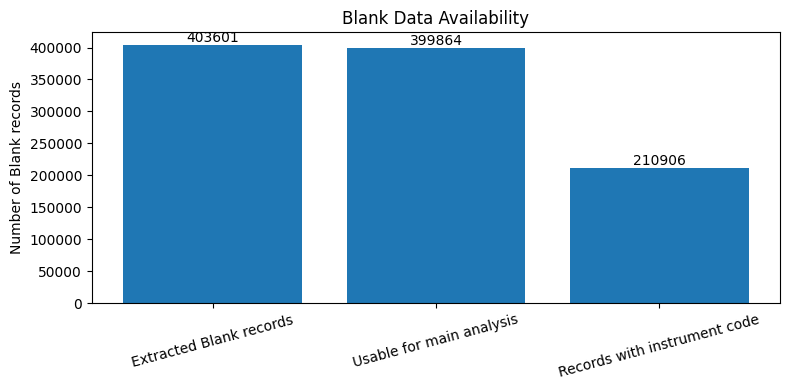

In [881]:
# Show how many Blank records are available for each part of the analysis
record_counts = {
    "Extracted Blank records": len(blank_df),
    "Usable for main analysis": len(analysis_df),
}

if "INSTRUMENT_CODE" in analysis_df.columns:
    record_counts["Records with instrument code"] = (
        analysis_df["INSTRUMENT_CODE"].notna().sum()
    )

plt.figure(figsize=(8, 4))
bars = plt.bar(record_counts.keys(), record_counts.values())

plt.ylabel("Number of Blank records")
plt.title("Blank Data Availability")

plt.bar_label(bars, fmt="%.0f")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

This confirms that sufficient historical Blank data is available for the anomaly analysis.

The main analysis compares Blank behaviour within each Scheme-Version-Analyte-Unit combination. Instrument information is assessed separately as contextual information because Blank limits are not instrument-specific.

The next stages identify unusual individual results and elevated trends, then compare these anomaly signals with the existing CCLAS classifications.

## 6. Exploratory analysis

This section provides a descriptive overview of the cleaned historical Blank results before anomaly detection is applied.

The analysis examines:

- the distribution of reported Blank values;
- the number of negative, zero and positive results;
- the overall spread of the reported values;
- the presence of unusually large positive or negative observations;
- the number of analytes, schemes, units and instruments represented;
- the existing CCLAS `STANDARD_STATUS` distribution.

Negative Blank results are retained unchanged. No results written with a less-than sign were identified in `NUMERIC_FINAL_VALUE`, so the available numeric QC results are used as supplied.

The overall numerical summary combines different schemes, scheme versions, analytes and measurement units and is therefore used only as a descriptive overview. It is not used to define Blank acceptance limits or anomaly thresholds.

All later statistical and anomaly-detection comparisons are performed within the correct Scheme-Version-Analyte-Unit combination. Instrument information is assessed separately as contextual information because Datamine confirmed that Blank limits are not instrument-specific.

In [882]:
# Summarise the distribution of cleaned Blank results
blank_summary = analysis_df["NUMERIC_FINAL_VALUE"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Blank result summary:")
display(
    blank_summary.to_frame(
        name="NUMERIC_FINAL_VALUE"
    )
)

# Count negative, zero and positive Blank results
zero_count = analysis_df["NUMERIC_FINAL_VALUE"].eq(0).sum()
negative_count = analysis_df["NUMERIC_FINAL_VALUE"].lt(0).sum()
positive_count = analysis_df["NUMERIC_FINAL_VALUE"].gt(0).sum()

print("Blank results equal to zero:", zero_count)
print("Negative Blank results:", negative_count)
print("Positive Blank results:", positive_count)

# Show the available analysis coverage
print("Unique schemes:", analysis_df["SCHEME_CODE"].nunique())

print(
    "Unique scheme versions:",
    analysis_df["SCHEME_VERSION"].nunique()
)

print("Unique analytes:", analysis_df["ANALYTE_CODE"].nunique())
print("Unique units:", analysis_df["UNIT_CODE"].nunique())

# Instrument is optional and used only for contextual summaries
if "INSTRUMENT_CODE" in analysis_df.columns:
    print(
        "Unique instruments available:",
        analysis_df["INSTRUMENT_CODE"].nunique()
    )

# Summarise the existing CCLAS Blank classifications for descriptive comparison only
status_summary = (
    analysis_df["STANDARD_STATUS"]
    .fillna("Missing")
    .value_counts(dropna=False)
    .rename_axis("STANDARD_STATUS")
    .reset_index(name="Blank records")
)

print("\nExisting CCLAS Blank status distribution:")
display(status_summary)

Blank result summary:


,NUMERIC_FINAL_VALUE
count,399864.000000
mean,4230.225995
std,43216.406150
min,-300.445200
1%,-1.524000
5%,-0.089987
25%,0.000000
50%,0.000090
75%,0.008480
95%,1.600000


Blank results equal to zero: 133882
Negative Blank results: 62514
Positive Blank results: 203468
Unique schemes: 33
Unique scheme versions: 4
Unique analytes: 77
Unique units: 3
Unique instruments available: 8

Existing CCLAS Blank status distribution:


,STANDARD_STATUS,Blank records
0,Pass,384612
1,UpperWarning,13634
2,IgnoredUpperFailure,1071
3,LowerWarning,350
4,UpperFailure,195
5,IgnoredLowerFailure,2


The overall Blank results are mostly concentrated close to zero, although larger positive and negative values are also present. These values cannot yet be classified as abnormal because the summary combines different Scheme-Version-Analyte-Unit combinations. The next analysis therefore examines comparable groups separately.

In [883]:
# Examine existing CCLAS Blank status classifications
status_counts = analysis_df["STANDARD_STATUS"].value_counts(dropna=False)

print("Blank STANDARD_STATUS summary:")
display(status_counts.to_frame(name="Count"))

Blank STANDARD_STATUS summary:


,Count
STANDARD_STATUS,
Pass,384612
UpperWarning,13634
IgnoredUpperFailure,1071
LowerWarning,350
UpperFailure,195
IgnoredLowerFailure,2


Existing CCLAS status: Most Blank records are classified as Pass. The remaining records include upper and lower warnings and failures. These existing classifications provide a baseline for what CCLAS already detects; the MVP will later focus on additional patterns such as elevated trends and instrument-level patterns.

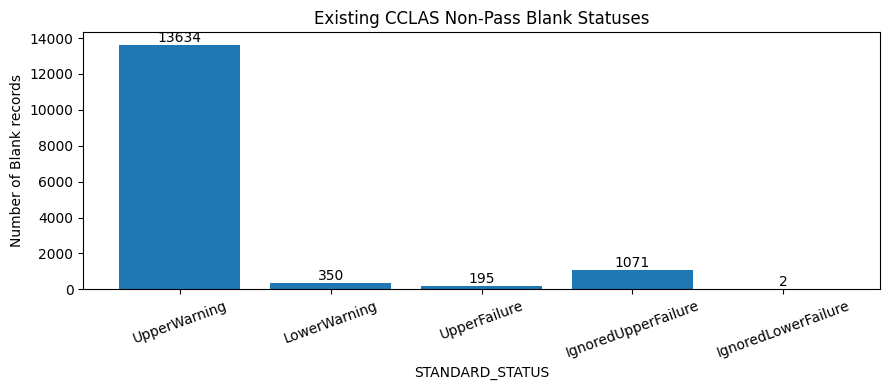

In [884]:
# Show the known existing non-Pass CCLAS Blank classifications
known_non_pass_statuses = [
    "UpperWarning",
    "LowerWarning",
    "UpperFailure",
    "LowerFailure",
    "IgnoredUpperFailure",
    "IgnoredLowerFailure",
]

non_pass_status = (
    status_counts
    .reindex(known_non_pass_statuses)
    .dropna()
)

plt.figure(figsize=(9, 4))

bars = plt.bar(
    non_pass_status.index,
    non_pass_status.values
)

plt.title("Existing CCLAS Non-Pass Blank Statuses")
plt.ylabel("Number of Blank records")
plt.xlabel("STANDARD_STATUS")

plt.bar_label(bars)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

This shows the existing non-Pass Blank classifications already identified by CCLAS. Upper Warnings are the most common. These statuses provide a comparison point for what CCLAS already detects. The anomaly-detection MVP will build on top of CCLAS by identifying additional abnormal behaviour, particularly unusual patterns and trends in results that may still be individually passing.

In [885]:
# Summarise existing CCLAS results by Scheme-Version-Analyte-Unit
group_columns = [
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

known_non_pass_statuses = [
    "UpperWarning",
    "LowerWarning",
    "UpperFailure",
    "LowerFailure",
    "IgnoredUpperFailure",
    "IgnoredLowerFailure",
]

group_status = (
    analysis_df
    .assign(
        NON_PASS=analysis_df["STANDARD_STATUS"].isin(
            known_non_pass_statuses
        )
    )
    .groupby(group_columns)
    .agg(
        TOTAL_RECORDS=("STANDARD_STATUS", "size"),
        NON_PASS_RECORDS=("NON_PASS", "sum")
    )
    .reset_index()
)

group_status["NON_PASS_PERCENT"] = (
    group_status["NON_PASS_RECORDS"]
    / group_status["TOTAL_RECORDS"]
    * 100
)

group_status = group_status.sort_values(
    "NON_PASS_RECORDS",
    ascending=False
)

display(group_status.head(20))

,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,TOTAL_RECORDS,NON_PASS_RECORDS,NON_PASS_PERCENT
746,PXRFRAW,2,ZR,PPM,1877,1862,99.200852
713,PXRFCOR,1,ZR,PPM,1845,1833,99.349593
722,PXRFRAW,2,FE,PPM,1875,1455,77.600000
689,PXRFCOR,1,FE,PPM,1845,1422,77.073171
732,PXRFRAW,2,RB,PPM,1877,1203,64.091636
699,PXRFCOR,1,RB,PPM,1845,1175,63.685637
712,PXRFCOR,1,ZN,PPM,1845,803,43.523035
745,PXRFRAW,2,ZN,PPM,1877,777,41.395844
739,PXRFRAW,2,TH,PPM,1876,493,26.279318
735,PXRFRAW,2,SE,PPM,1876,478,25.479744


This shows that existing CCLAS non-Pass classifications are concentrated in certain Scheme-Version-Analyte-Unit combinations. For example, almost all ZR Blank results in the PXRFCOR and PXRFRAW groups are already classified as non-Pass. This supports analysing each Scheme-Version-Analyte-Unit separately rather than applying one rule across all Blank results.

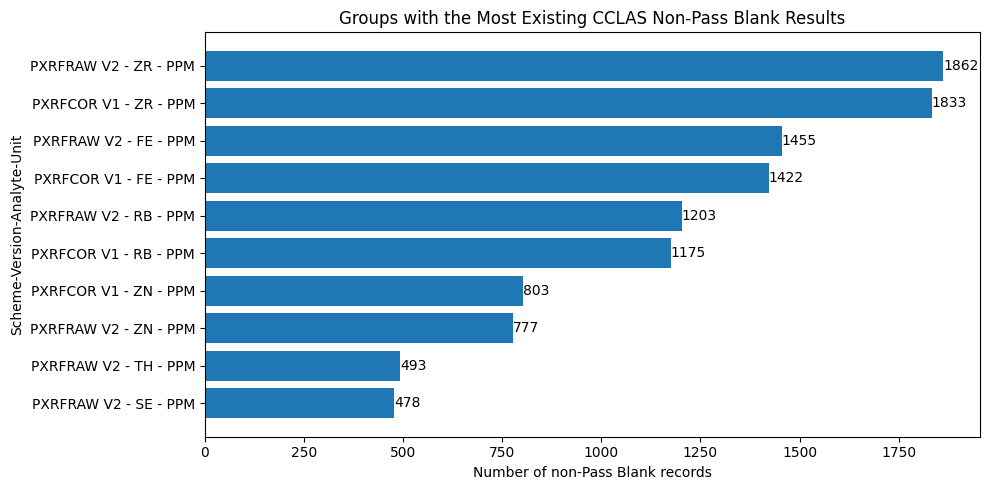

In [886]:
# Show the 10 groups with the most existing non-Pass records
top_groups = group_status.head(10).copy()

top_groups["GROUP"] = (
    top_groups["SCHEME_CODE"].astype(str)
    + " V" + top_groups["SCHEME_VERSION"].astype(str)
    + " - " + top_groups["ANALYTE_CODE"].astype(str)
    + " - " + top_groups["UNIT_CODE"].astype(str)
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_groups["GROUP"],
    top_groups["NON_PASS_RECORDS"]
)

plt.xlabel("Number of non-Pass Blank records")
plt.ylabel("Scheme-Version-Analyte-Unit")
plt.title("Groups with the Most Existing CCLAS Non-Pass Blank Results")

plt.bar_label(bars)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This graph shows which Scheme-Version-Analyte-Unit groups contain the largest number of Blank results already classified as non-Pass by CCLAS. ZR has the highest counts, with 1,862 non-Pass results in PXRFRAW V2 and 1,833 in PXRFCOR V1. This shows that existing non-Pass classifications are concentrated in particular Blank groups and supports analysing each Scheme-Version-Analyte-Unit separately rather than treating all Blank results the same.

### Instrument-level Blank summary

Datamine confirmed that Blank limits are not instrument-specific, so results from all instruments are assessed against the same expected Blank limits.

However, if a particular instrument shows more Blank failures than other instruments, this should be highlighted in the final summary.

The following analysis therefore compares existing CCLAS Blank classifications across records with an available `INSTRUMENT_CODE`. Warnings, active failures and ignored failures are kept separate, and both counts and rates are reported because instruments may have different numbers of Blank records.

In [887]:
# Summarise existing CCLAS results by instrument
instrument_df = analysis_df[
    analysis_df["INSTRUMENT_CODE"].notna()
].copy()

# Keep different existing CCLAS outcomes separate
instrument_df["CCLAS_WARNING"] = instrument_df[
    "STANDARD_STATUS"
].isin([
    "UpperWarning",
    "LowerWarning",
])

instrument_df["CCLAS_ACTIVE_FAILURE"] = instrument_df[
    "STANDARD_STATUS"
].isin([
    "UpperFailure",
    "LowerFailure",
])

instrument_df["CCLAS_IGNORED_FAILURE"] = instrument_df[
    "STANDARD_STATUS"
].isin([
    "IgnoredUpperFailure",
    "IgnoredLowerFailure",
])

instrument_summary = (
    instrument_df
    .groupby("INSTRUMENT_CODE")
    .agg(
        TOTAL_RECORDS=("STANDARD_STATUS", "size"),
        WARNING_RECORDS=("CCLAS_WARNING", "sum"),
        ACTIVE_FAILURE_RECORDS=("CCLAS_ACTIVE_FAILURE", "sum"),
        IGNORED_FAILURE_RECORDS=("CCLAS_IGNORED_FAILURE", "sum"),
    )
    .reset_index()
)

# Calculate rates because instruments may have different numbers of Blank records
instrument_summary["WARNING_PERCENT"] = (
    instrument_summary["WARNING_RECORDS"]
    / instrument_summary["TOTAL_RECORDS"]
    * 100
)

instrument_summary["ACTIVE_FAILURE_PERCENT"] = (
    instrument_summary["ACTIVE_FAILURE_RECORDS"]
    / instrument_summary["TOTAL_RECORDS"]
    * 100
)

instrument_summary["IGNORED_FAILURE_PERCENT"] = (
    instrument_summary["IGNORED_FAILURE_RECORDS"]
    / instrument_summary["TOTAL_RECORDS"]
    * 100
)

# Rank instruments by active CCLAS failure rate,
# then by the number of active failures
instrument_summary = instrument_summary.sort_values(
    [
        "ACTIVE_FAILURE_PERCENT",
        "ACTIVE_FAILURE_RECORDS",
    ],
    ascending=False
).reset_index(drop=True)

display(instrument_summary)

,INSTRUMENT_CODE,TOTAL_RECORDS,WARNING_RECORDS,ACTIVE_FAILURE_RECORDS,IGNORED_FAILURE_RECORDS,WARNING_PERCENT,ACTIVE_FAILURE_PERCENT,IGNORED_FAILURE_PERCENT
0,PHOTON,31,0,14,0,0.000000,45.161290,0.000000
1,PE_ICPOES,16286,4,57,38,0.024561,0.349994,0.233329
2,AGILENT_ICPMS,45540,0,29,11,0.000000,0.063680,0.024155
3,PE_ICPMS,62986,147,18,9,0.233385,0.028578,0.014289
4,PXRF_IMPORT,64583,6854,14,515,10.612700,0.021678,0.797423
5,AGILENT_AAS,10903,0,2,0,0.000000,0.018344,0.000000
6,AGILENT_AAS_2,10396,0,0,0,0.000000,0.000000,0.000000
7,INDF_CS,181,0,0,0,0.000000,0.000000,0.000000


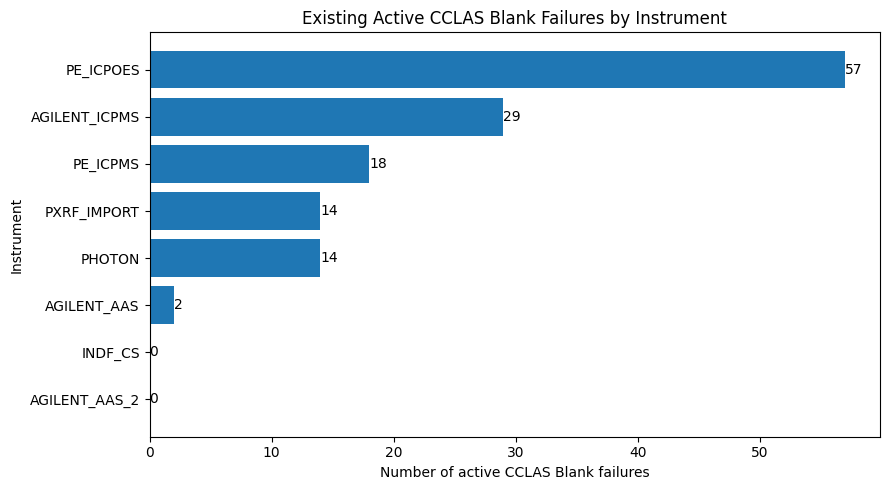

In [888]:
# Visualise existing active CCLAS Blank failures by instrument
plot_data = instrument_summary.sort_values(
    "ACTIVE_FAILURE_RECORDS",
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_data["INSTRUMENT_CODE"],
    plot_data["ACTIVE_FAILURE_RECORDS"]
)

plt.xlabel("Number of active CCLAS Blank failures")
plt.ylabel("Instrument")
plt.title("Existing Active CCLAS Blank Failures by Instrument")

plt.bar_label(bars)
plt.tight_layout()
plt.show()

For records with an available instrument code, `PE_ICPOES` has the highest number of existing active CCLAS Blank failures with 57 records. `PHOTON` has the highest active-failure rate at 45.16%, although this is based on only 31 Blank records. These results describe instrument-level patterns already identified by CCLAS and do not imply that different Blank limits should be applied to different instruments. Warning and ignored-failure classifications are retained separately from active failures.

CCLAS already flags individual failures, but the client also wants elevated behaviour as a trend while the individual results may still be passing.

## 7. Blank feature engineering

Anomaly-detection features are created within each Scheme-Version-Analyte-Unit combination so that each Blank result is compared only with historically comparable Blank behaviour.

The features describe temporal and statistical behaviour, including the previous result, change between consecutive results and deviation from typical behaviour within the same Scheme-Version-Analyte-Unit group.

These features are created independently of the existing CCLAS `STANDARD_STATUS` classification. CCLAS Warning and Failure classifications are retained only for later comparison with the anomaly-detection results and are not used to train or define the anomaly detector.

No new CCLAS Warning or Action limits are created or inferred by the anomaly-detection workflow. The purpose of this stage is to identify unusual point and temporal behaviour that can add information beyond the individual-result checks already performed by CCLAS.

In [889]:
# Remove obsolete feature columns from earlier notebook versions
old_feature_columns = [
    "TARGET_DEVIATION",
    "ZERO_MAD_GROUP",
    "ROBUST_Z_SCORE",
    "ROLLING_MEDIAN",
    "ROLLING_CHANGE",
    "GROUP_MEDIAN",
    "ABS_MEDIAN_DEVIATION",
    "GROUP_MAD",
    "GROUP_SIZE",
    "PRIOR_COUNT",
    "PREVIOUS_VALUE",
    "CHANGE_FROM_PREVIOUS",
    "ABS_CHANGE_FROM_PREVIOUS",
    "TIME_SINCE_PREVIOUS_HOURS",
    "PRIOR_MEDIAN",
    "PRIOR_Q25",
    "PRIOR_Q75",
    "PRIOR_IQR",
    "ABS_DEVIATION_FROM_PRIOR_MEDIAN",
]

analysis_df = analysis_df.drop(
    columns=old_feature_columns,
    errors="ignore"
)

# Datamine-confirmed Blank comparison context:
# Scheme-Version-Analyte-Unit.
# Instrument is deliberately NOT included because Blank limits
# and comparable Blank behaviour are not instrument-specific.
GROUP_COLUMNS = [
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

# Keep comparable Blank records in chronological order.
# ANALYSED_DATE is the available time reference in this dataset.
# It is not assumed to represent an exact laboratory run sequence.
analysis_df = (
    analysis_df
    .sort_values(
        GROUP_COLUMNS + ["ANALYSED_DATE"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

# Group only the measured Blank result.
# STANDARD_STATUS is deliberately excluded from feature creation
# because the anomaly detector must be independent of CCLAS.
value_groups = analysis_df.groupby(
    GROUP_COLUMNS,
    sort=False
)["NUMERIC_FINAL_VALUE"]

# Number of historical observations available BEFORE each result
analysis_df["PRIOR_COUNT"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )
    .cumcount()
)

# Previous Blank result within the same
# Scheme-Version-Analyte-Unit combination
analysis_df["PREVIOUS_VALUE"] = (
    value_groups.shift(1)
)

# Change from the previous comparable Blank result
analysis_df["CHANGE_FROM_PREVIOUS"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["PREVIOUS_VALUE"]
)

# Magnitude of the change regardless of direction
analysis_df["ABS_CHANGE_FROM_PREVIOUS"] = (
    analysis_df["CHANGE_FROM_PREVIOUS"].abs()
)

# Time between consecutive recorded results in the same comparison group
analysis_df["TIME_SINCE_PREVIOUS_HOURS"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["ANALYSED_DATE"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)

# Historical median using ONLY results that occurred before
# the current observation.
#
# shift(1) is essential because it prevents the current result
# from contributing to its own historical reference.
analysis_df["PRIOR_MEDIAN"] = (
    value_groups.transform(
        lambda s: (
            s.shift(1)
            .expanding(min_periods=1)
            .median()
        )
    )
)

# Historical lower quartile using prior observations only
analysis_df["PRIOR_Q25"] = (
    value_groups.transform(
        lambda s: (
            s.shift(1)
            .expanding(min_periods=1)
            .quantile(0.25)
        )
    )
)

# Historical upper quartile using prior observations only
analysis_df["PRIOR_Q75"] = (
    value_groups.transform(
        lambda s: (
            s.shift(1)
            .expanding(min_periods=1)
            .quantile(0.75)
        )
    )
)

# Historical interquartile range
analysis_df["PRIOR_IQR"] = (
    analysis_df["PRIOR_Q75"]
    - analysis_df["PRIOR_Q25"]
)

# Distance between the current result and the historical median.
# This is an anomaly feature only.
# It is NOT a CCLAS Warning or Action limit.
analysis_df["ABS_DEVIATION_FROM_PRIOR_MEDIAN"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["PRIOR_MEDIAN"]
).abs()

print("Blank anomaly feature engineering complete.")

display(
    analysis_df[
        GROUP_COLUMNS
        + [
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "PRIOR_COUNT",
            "PREVIOUS_VALUE",
            "CHANGE_FROM_PREVIOUS",
            "ABS_CHANGE_FROM_PREVIOUS",
            "TIME_SINCE_PREVIOUS_HOURS",
            "PRIOR_MEDIAN",
            "PRIOR_Q25",
            "PRIOR_Q75",
            "PRIOR_IQR",
            "ABS_DEVIATION_FROM_PRIOR_MEDIAN",
        ]
    ].head(10)
)

Blank anomaly feature engineering complete.


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PRIOR_COUNT,PREVIOUS_VALUE,CHANGE_FROM_PREVIOUS,ABS_CHANGE_FROM_PREVIOUS,TIME_SINCE_PREVIOUS_HOURS,PRIOR_MEDIAN,PRIOR_Q25,PRIOR_Q75,PRIOR_IQR,ABS_DEVIATION_FROM_PRIOR_MEDIAN
0,AR10_AU,1,AU,PPB,2019-07-04 07:57:11,-0.47114,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AR10_AU,1,AU,PPB,2019-08-14 10:03:59,-0.50287,1,-0.47114,-0.03173,0.03173,986.113333,-0.471140,-0.471140,-0.471140,0.000000,0.031730
2,AR10_AU,1,AU,PPB,2019-08-14 10:04:43,-0.24679,2,-0.50287,0.25608,0.25608,0.012222,-0.487005,-0.494938,-0.479073,0.015865,0.240215
3,AR10_AU,1,AU,PPB,2019-08-14 10:05:28,-0.34447,3,-0.24679,-0.09768,0.09768,0.012500,-0.471140,-0.487005,-0.358965,0.128040,0.126670
4,AR10_AU,1,AU,PPB,2019-08-14 10:07:16,-0.50210,4,-0.34447,-0.15763,0.15763,0.030000,-0.407805,-0.479073,-0.320050,0.159023,0.094295
5,AR10_AU,1,AU,PPB,2019-08-14 10:43:09,0.03274,5,-0.50210,0.53484,0.53484,0.598056,-0.471140,-0.502100,-0.344470,0.157630,0.503880
6,AR10_AU,1,AU,PPB,2019-08-14 14:24:29,-0.10969,6,0.03274,-0.14243,0.14243,3.688889,-0.407805,-0.494360,-0.271210,0.223150,0.298115
7,AR10_AU,1,AU,PPB,2019-08-15 07:27:05,-1.00017,7,-0.10969,-0.89048,0.89048,17.043333,-0.344470,-0.486620,-0.178240,0.308380,0.655700
8,AR10_AU,1,AU,PPB,2019-08-15 07:31:17,-1.30955,8,-1.00017,-0.30938,0.30938,0.070000,-0.407805,-0.502293,-0.212515,0.289778,0.901745
9,AR10_AU,1,AU,PPB,2019-08-15 07:35:30,-2.04846,9,-1.30955,-0.73891,0.73891,0.070278,-0.471140,-0.502870,-0.246790,0.256080,1.577320


Refer to table

These engineered features describe how each Blank result behaves over time relative to prior results within its own Scheme-Version-Analyte-Unit history.

The features include the previous Blank result, the change from the previous result, time since the previous recorded result, historical median and quartiles calculated from prior observations, historical interquartile range, and the distance of the current result from its prior historical median.

Only observations occurring before the current result are used to construct its historical reference features. This prevents the current result or later observations from influencing its own anomaly assessment.

These features do not classify a result as a CCLAS Warning, Failure or anomaly and do not use `STANDARD_STATUS` to define abnormal behaviour. They prepare the measured Blank data for the subsequent point, collective/trend and contextual anomaly-detection stages.


The engineered features compare each Blank result only with prior observations from the same Scheme-Version-Analyte-Unit combination.

The previous-result and change features describe short-term movement between consecutive recorded Blank results. The prior median and quartiles describe the historical behaviour available before the current result, while the prior interquartile range describes the spread of that earlier history. The absolute deviation from the prior median measures how far the current result is from its previous typical behaviour.

Missing historical feature values at the beginning of a group are expected because there may be little or no prior history available. These values are left as missing rather than being replaced with zero.

These features are used to support later point and trend anomaly detection. They do not reproduce CCLAS Warning or Failure logic, do not use `STANDARD_STATUS` to define abnormal behaviour, and do not by themselves confirm contamination or any other laboratory cause.

## 8. Blank anomaly assessment

This section assesses three forms of abnormal Blank behaviour:

- **Point anomalies:** unusual individual Blank results relative to prior comparable Blank behaviour.
- **Collective anomalies:** unusual patterns or persistent changes across multiple Blank results over time.
- **Contextual anomalies:** concentration of unusual Blank behaviour associated with particular instruments.

CCLAS already identifies individual Warning and Failure results. The anomaly-detection MVP operates as an additional layer, with particular emphasis on unusual behaviour and trends that may occur while individual results are still classified as Pass by CCLAS.

No new CCLAS Warning or Action limits are created or inferred from the historical `QC_Sample_Data.csv` data. Statistical and machine-learning methods used for anomaly detection are POC methods and remain separate from Datamine's configured QC rules.

Instrument information is not used to define separate Blank limits or the primary Scheme-Version-Analyte-Unit comparison groups. Instrument-level behaviour is assessed contextually after the result-level anomaly signals have been calculated.

In [890]:
# Retain existing CCLAS classifications for later comparison only.
# Only recognised CCLAS Warning/Failure statuses are treated as non-Pass.
known_non_pass_statuses = [
    "UpperWarning",
    "LowerWarning",
    "UpperFailure",
    "LowerFailure",
    "IgnoredUpperFailure",
    "IgnoredLowerFailure",
]

analysis_df["CCLAS_NON_PASS"] = (
    analysis_df["STANDARD_STATUS"].isin(known_non_pass_statuses)
)

# Keep existing CCLAS outcome types separate.
analysis_df["CCLAS_WARNING"] = (
    analysis_df["STANDARD_STATUS"].isin([
        "UpperWarning",
        "LowerWarning",
    ])
)

analysis_df["CCLAS_ACTIVE_FAILURE"] = (
    analysis_df["STANDARD_STATUS"].isin([
        "UpperFailure",
        "LowerFailure",
    ])
)

analysis_df["CCLAS_IGNORED_FAILURE"] = (
    analysis_df["STANDARD_STATUS"].isin([
        "IgnoredUpperFailure",
        "IgnoredLowerFailure",
    ])
)

# Indicates whether at least one earlier comparable Blank result exists.
# This does not by itself mean there is enough history for trend detection.
analysis_df["HAS_PREVIOUS_RESULT"] = (
    analysis_df["PREVIOUS_VALUE"].notna()
)

# Indicates whether prior historical reference features are available.
analysis_df["HISTORICAL_FEATURES_AVAILABLE"] = (
    analysis_df["PRIOR_MEDIAN"].notna()
)

print(
    "Existing CCLAS non-Pass Blank results:",
    analysis_df["CCLAS_NON_PASS"].sum()
)

print(
    "Existing active CCLAS Blank failures:",
    analysis_df["CCLAS_ACTIVE_FAILURE"].sum()
)

print(
    "Rows with at least one previous comparable Blank result:",
    analysis_df["HAS_PREVIOUS_RESULT"].sum()
)

print(
    "Rows with historical reference features:",
    analysis_df["HISTORICAL_FEATURES_AVAILABLE"].sum()
)

if "INSTRUMENT_CODE" in analysis_df.columns:
    print(
        "Rows with instrument information:",
        analysis_df["INSTRUMENT_CODE"].notna().sum()
    )

Existing CCLAS non-Pass Blank results: 15252
Existing active CCLAS Blank failures: 195
Rows with at least one previous comparable Blank result: 399113
Rows with historical reference features: 399113
Rows with instrument information: 210906


## 9. Remaining Datamine clarifications

The anomaly-detection model is developed independently of `STANDARD_STATUS`. Existing CCLAS classifications are retained only for comparison with the anomaly-detection results.

Two implementation details remain to be confirmed by Datamine:

- Which field identifies the single batch/LabBatch that should be used when aggregating Blank alerts?
- How should `IgnoredUpperFailure` and `IgnoredLowerFailure` be interpreted and presented in the final summary?

These unresolved details do not prevent development of the result-level point, trend and contextual anomaly-detection components.

## 10. Blank trend analysis

Datamine confirmed that CCLAS already identifies individual Blank Warning and Failure results, while the anomaly-detection MVP should also identify elevated or drifting behaviour that may form a pattern even when individual results are not failing.

Trend analysis is performed independently of the existing CCLAS `STANDARD_STATUS`. Blank measurements are assessed chronologically within their own Scheme-Version-Analyte-Unit combination using only historical observations that occurred before the current result.

The trend-detection methods are designed to identify persistent movement or shifts in Blank behaviour rather than only isolated extreme results. This includes gradual changes and sustained elevated or shifted behaviour.

Datamine has not specified a fixed number of consecutive observations that constitutes a trend. Any rolling-window, persistence or change-detection parameters used in this MVP are therefore treated as POC modelling parameters rather than Datamine-defined QC rules.

After trend signals have been calculated, they are compared with the existing CCLAS classifications. Of particular interest are trend anomalies occurring in results that CCLAS still classifies as Pass, because these represent potential additional information provided by the anomaly-detection layer.

In [891]:
# POC trend-detection parameters.
# These are modelling choices for the MVP, NOT Datamine-defined QC rules.
POC_TREND_WINDOW = 5
POC_MIN_PRIOR_HISTORY = 10
POC_REQUIRED_OUTSIDE = 4

# Ensure records remain chronological within each Datamine Blank comparison group
analysis_df = (
    analysis_df
    .sort_values(
        GROUP_COLUMNS + ["ANALYSED_DATE"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

# A result has sufficient historical context for the POC trend method
analysis_df["TREND_HISTORY_READY"] = (
    analysis_df["PRIOR_COUNT"] >= POC_MIN_PRIOR_HISTORY
)

# Position of each result relative to its own PRIOR historical distribution.
# These are anomaly features, not CCLAS Warning or Action limits.
analysis_df["ABOVE_PRIOR_Q75"] = (
    analysis_df["PRIOR_Q75"].notna()
    & (
        analysis_df["NUMERIC_FINAL_VALUE"]
        > analysis_df["PRIOR_Q75"]
    )
)

analysis_df["BELOW_PRIOR_Q25"] = (
    analysis_df["PRIOR_Q25"].notna()
    & (
        analysis_df["NUMERIC_FINAL_VALUE"]
        < analysis_df["PRIOR_Q25"]
    )
)

# Recent median of the measured Blank values.
# This window ends at the current result and never uses future observations.
analysis_df["RECENT_MEDIAN"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["NUMERIC_FINAL_VALUE"]
    .transform(
        lambda s: s.rolling(
            window=POC_TREND_WINDOW,
            min_periods=POC_TREND_WINDOW
        ).median()
    )
)

# Count how many results in the recent window are above
# their own prior upper quartile
analysis_df["RECENT_ABOVE_Q75_COUNT"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["ABOVE_PRIOR_Q75"]
    .transform(
        lambda s: s.rolling(
            window=POC_TREND_WINDOW,
            min_periods=POC_TREND_WINDOW
        ).sum()
    )
)

# Count how many results in the recent window are below
# their own prior lower quartile
analysis_df["RECENT_BELOW_Q25_COUNT"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["BELOW_PRIOR_Q25"]
    .transform(
        lambda s: s.rolling(
            window=POC_TREND_WINDOW,
            min_periods=POC_TREND_WINDOW
        ).sum()
    )
)

# Confirm that every result in the recent window had enough
# prior history for the POC trend assessment
analysis_df["RECENT_HISTORY_READY_COUNT"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["TREND_HISTORY_READY"]
    .transform(
        lambda s: s.rolling(
            window=POC_TREND_WINDOW,
            min_periods=POC_TREND_WINDOW
        ).sum()
    )
)

# Persistent upward behaviour:
# - all observations in the window have sufficient prior history;
# - at least 4 of the latest 5 are above their prior Q75;
# - the recent median is also above the historical Q75.
analysis_df["UPWARD_TREND_CANDIDATE"] = (
    analysis_df["RECENT_HISTORY_READY_COUNT"].eq(
        POC_TREND_WINDOW
    )
    & analysis_df["RECENT_ABOVE_Q75_COUNT"].ge(
        POC_REQUIRED_OUTSIDE
    )
    & (
        analysis_df["RECENT_MEDIAN"]
        > analysis_df["PRIOR_Q75"]
    )
)

# Persistent downward behaviour is retained as a separate
# anomaly direction because Blank values can be negative and
# Datamine also defines lower QC limits.
analysis_df["DOWNWARD_TREND_CANDIDATE"] = (
    analysis_df["RECENT_HISTORY_READY_COUNT"].eq(
        POC_TREND_WINDOW
    )
    & analysis_df["RECENT_BELOW_Q25_COUNT"].ge(
        POC_REQUIRED_OUTSIDE
    )
    & (
        analysis_df["RECENT_MEDIAN"]
        < analysis_df["PRIOR_Q25"]
    )
)

analysis_df["TREND_CANDIDATE"] = (
    analysis_df["UPWARD_TREND_CANDIDATE"]
    | analysis_df["DOWNWARD_TREND_CANDIDATE"]
)

analysis_df["TREND_DIRECTION"] = np.select(
    [
        analysis_df["UPWARD_TREND_CANDIDATE"],
        analysis_df["DOWNWARD_TREND_CANDIDATE"],
    ],
    [
        "Upward",
        "Downward",
    ],
    default="None"
)

# Compare against CCLAS only AFTER the independent
# trend signal has been calculated.
analysis_df["CCLAS_PASS_TREND_CANDIDATE"] = (
    analysis_df["TREND_CANDIDATE"]
    & analysis_df["STANDARD_STATUS"].eq("Pass")
)

print("POC trend window:", POC_TREND_WINDOW)
print("Minimum prior history:", POC_MIN_PRIOR_HISTORY)
print(
    "Upward trend candidates:",
    analysis_df["UPWARD_TREND_CANDIDATE"].sum()
)
print(
    "Downward trend candidates:",
    analysis_df["DOWNWARD_TREND_CANDIDATE"].sum()
)
print(
    "Total trend candidates:",
    analysis_df["TREND_CANDIDATE"].sum()
)
print(
    "Trend candidates currently classified as Pass by CCLAS:",
    analysis_df["CCLAS_PASS_TREND_CANDIDATE"].sum()
)

display(
    analysis_df.loc[
        analysis_df["TREND_CANDIDATE"],
        GROUP_COLUMNS
        + [
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "PRIOR_COUNT",
            "PRIOR_MEDIAN",
            "PRIOR_Q25",
            "PRIOR_Q75",
            "RECENT_MEDIAN",
            "RECENT_ABOVE_Q75_COUNT",
            "RECENT_BELOW_Q25_COUNT",
            "TREND_DIRECTION",
            "STANDARD_STATUS",
            "CCLAS_PASS_TREND_CANDIDATE",
        ]
    ].head(20)
)

POC trend window: 5
Minimum prior history: 10
Upward trend candidates: 19236
Downward trend candidates: 18021
Total trend candidates: 37257
Trend candidates currently classified as Pass by CCLAS: 35194


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PRIOR_COUNT,PRIOR_MEDIAN,PRIOR_Q25,PRIOR_Q75,RECENT_MEDIAN,RECENT_ABOVE_Q75_COUNT,RECENT_BELOW_Q25_COUNT,TREND_DIRECTION,STANDARD_STATUS,CCLAS_PASS_TREND_CANDIDATE
15,AR10_AU,1,AU,PPB,2019-08-16 10:54:21,-1.474430,15,-0.502870,-1.145050,-0.331965,-1.289930,0.0,4.0,Downward,Pass,True
24,AR10_AU,1,AU,PPB,2019-08-20 11:45:09,-1.911820,24,-0.856180,-1.294835,-0.458608,-1.429950,0.0,4.0,Downward,Pass,True
25,AR10_AU,1,AU,PPB,2019-08-20 11:52:44,-2.212070,25,-0.856250,-1.309550,-0.471140,-1.910070,0.0,4.0,Downward,Pass,True
44,AR10_AU,1,AU,PPB,2019-08-23 10:59:49,0.005440,44,-0.728688,-1.270857,-0.301293,-0.119216,4.0,0.0,Upward,Pass,True
45,AR10_AU,1,AU,PPB,2019-08-23 11:01:55,-0.124208,45,-0.728088,-1.264500,-0.246790,-0.119216,5.0,0.0,Upward,Pass,True
46,AR10_AU,1,AU,PPB,2019-08-23 11:04:17,0.212152,46,-0.726644,-1.258920,-0.219513,-0.119216,5.0,0.0,Upward,Pass,True
47,AR10_AU,1,AU,PPB,2019-08-26 12:31:23,-0.498336,47,-0.725200,-1.253340,-0.167314,-0.124208,4.0,0.0,Upward,Pass,True
48,AR10_AU,1,AU,PPB,2019-08-26 16:00:15,0.116340,48,-0.706828,-1.247760,-0.188867,0.005440,4.0,0.0,Upward,Pass,True
96,AR10_AU,1,AU,PPB,2019-09-24 17:22:32,0.275930,96,-0.483310,-0.907745,0.006063,0.213730,4.0,0.0,Upward,Pass,True
97,AR10_AU,1,AU,PPB,2019-09-24 17:22:48,-0.144620,97,-0.471140,-0.898570,0.007930,0.213730,4.0,0.0,Upward,Pass,True


In [892]:
# Convert consecutive trend-candidate rows into trend episodes.
# This does not introduce a new anomaly threshold.
# It only groups repeated candidate rows from the same sustained pattern.

analysis_df = (
    analysis_df
    .sort_values(
        GROUP_COLUMNS + ["ANALYSED_DATE"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

trend_group = analysis_df.groupby(
    GROUP_COLUMNS,
    sort=False
)

# Previous candidate state and direction within the same
# Scheme-Version-Analyte-Unit history
previous_trend_candidate = (
    trend_group["TREND_CANDIDATE"]
    .shift(1)
    .fillna(False)
)

previous_trend_direction = (
    trend_group["TREND_DIRECTION"]
    .shift(1)
)

# A new episode begins when:
# - a trend candidate appears after a non-candidate result, or
# - the detected trend direction changes.
analysis_df["TREND_EPISODE_START"] = (
    analysis_df["TREND_CANDIDATE"]
    & (
        ~previous_trend_candidate
        | (
            analysis_df["TREND_DIRECTION"]
            != previous_trend_direction
        )
    )
)

# Number trend episodes independently within each
# Scheme-Version-Analyte-Unit group
analysis_df["TREND_EPISODE_NUMBER"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["TREND_EPISODE_START"]
    .cumsum()
)

# Keep only rows that actually belong to a detected trend
trend_rows = analysis_df[
    analysis_df["TREND_CANDIDATE"]
].copy()

# Summarise each sustained trend episode
trend_episode_summary = (
    trend_rows
    .groupby(
        GROUP_COLUMNS
        + [
            "TREND_DIRECTION",
            "TREND_EPISODE_NUMBER",
        ],
        sort=False
    )
    .agg(
        START_DATE=("ANALYSED_DATE", "min"),
        END_DATE=("ANALYSED_DATE", "max"),
        RESULT_COUNT=("NUMERIC_FINAL_VALUE", "size"),
        MIN_VALUE=("NUMERIC_FINAL_VALUE", "min"),
        MAX_VALUE=("NUMERIC_FINAL_VALUE", "max"),
        MEDIAN_VALUE=("NUMERIC_FINAL_VALUE", "median"),
        CCLAS_PASS_RESULTS=(
            "STANDARD_STATUS",
            lambda s: s.eq("Pass").sum()
        ),
        JOB_COUNT=("JOB_NAME_ANON", "nunique"),
        INSTRUMENT_COUNT=("INSTRUMENT_CODE", "nunique"),
    )
    .reset_index()
)

# Duration is descriptive only.
# It is based on ANALYSED_DATE and is not treated as
# the exact laboratory analytical sequence.
trend_episode_summary["DURATION_HOURS"] = (
    (
        trend_episode_summary["END_DATE"]
        - trend_episode_summary["START_DATE"]
    )
    .dt.total_seconds()
    .div(3600)
)

# Identify episodes where all candidate results remained
# individually classified as Pass by CCLAS.
trend_episode_summary["ALL_RESULTS_CCLAS_PASS"] = (
    trend_episode_summary["CCLAS_PASS_RESULTS"]
    == trend_episode_summary["RESULT_COUNT"]
)

trend_episode_summary = (
    trend_episode_summary
    .sort_values(
        [
            "RESULT_COUNT",
            "START_DATE",
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print(
    "Trend candidate rows:",
    len(trend_rows)
)

print(
    "Distinct trend episodes:",
    len(trend_episode_summary)
)

print(
    "Episodes containing only CCLAS Pass results:",
    trend_episode_summary[
        "ALL_RESULTS_CCLAS_PASS"
    ].sum()
)

print(
    "Upward trend episodes:",
    trend_episode_summary[
        "TREND_DIRECTION"
    ].eq("Upward").sum()
)

print(
    "Downward trend episodes:",
    trend_episode_summary[
        "TREND_DIRECTION"
    ].eq("Downward").sum()
)

display(
    trend_episode_summary.head(20)
)

/var/folders/50/8f_xc_fn2fn8ttr0vjcw56gc0000gn/T/ipykernel_79122/2850842067.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Trend candidate rows: 37257
Distinct trend episodes: 10079
Episodes containing only CCLAS Pass results: 9472
Upward trend episodes: 5151
Downward trend episodes: 4928


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,TREND_DIRECTION,TREND_EPISODE_NUMBER,START_DATE,END_DATE,RESULT_COUNT,MIN_VALUE,MAX_VALUE,MEDIAN_VALUE,CCLAS_PASS_RESULTS,JOB_COUNT,INSTRUMENT_COUNT,DURATION_HOURS,ALL_RESULTS_CCLAS_PASS
0,AR10_MS,2,AS,PPM,Upward,14,2021-01-18 15:30:14,2021-07-07 12:05:32,131,0.044000,0.499800,0.280000,131,131,1,4076.588333,True
1,MA40_OES,1,S,%,Upward,144,2020-06-02 19:56:12,2020-06-18 06:19:17,125,0.000479,0.005841,0.003510,125,125,0,370.384722,True
2,MA40_OES,1,TI,%,Downward,26,2020-05-13 17:38:19,2020-06-25 08:42:12,119,0.000039,0.001387,0.000408,119,119,0,1023.064722,True
3,MA40_OES,1,S,%,Upward,160,2020-08-13 20:11:44,2020-09-02 13:21:21,98,0.001891,0.006100,0.003192,98,98,0,473.160278,True
4,MA40_OES,1,TI,%,Downward,30,2020-07-27 13:39:57,2020-09-10 09:45:10,95,0.000062,0.001188,0.000199,95,95,0,1076.086944,True
5,MA40_OES,1,S,%,Upward,143,2020-05-20 20:27:58,2020-06-02 16:08:27,88,-0.003322,0.004705,0.002970,88,88,0,307.674722,True
6,MA40_OES,1,W,PPM,Downward,142,2020-12-02 18:40:13,2020-12-18 09:24:18,79,-6.367000,0.649000,-3.912000,79,79,1,374.734722,True
7,AR10_MS,2,SN,PPM,Downward,29,2021-09-20 15:10:13,2021-10-05 16:17:00,74,-0.034890,0.015200,0.003812,74,74,2,361.113056,True
8,MA40_OES,1,TI,%,Downward,27,2020-06-26 11:38:34,2020-07-14 15:36:08,71,0.000075,0.003662,0.000205,71,71,0,435.959444,True
9,AR10_MS,2,AS,PPM,Upward,31,2021-11-12 12:41:25,2021-12-20 15:06:38,68,0.000000,0.584000,0.400000,67,68,1,914.420278,False


The trend screen identified 37,257 candidate rows, grouped into 10,079 consecutive runs within their Scheme-Version-Analyte-Unit histories. Of these, 5,151 were upward, 4,928 were downward, and 9,472 contained only results classified as Pass by CCLAS.

These are candidate patterns for analyst review, not confirmed Blank failures or contamination events. Because Datamine identifies gradual upward Blank drift as the main collective anomaly pattern, upward/elevated behaviour is retained as the primary trend signal, while downward patterns remain exploratory.

`STANDARD_STATUS` is used only after trend detection to compare the new anomaly signals with what CCLAS already identifies.

In [893]:
# Datamine-aligned collective Blank anomaly:
# retain elevated/upward trend candidates as the primary trend signal.
#
# Downward behaviour is preserved separately for exploratory review,
# but is not treated as the MVP's primary Blank trend alert because
# Datamine specifically requested elevated Blank behaviour/trends.

analysis_df["ELEVATED_TREND_CANDIDATE"] = (
    analysis_df["UPWARD_TREND_CANDIDATE"]
)

analysis_df["CCLAS_PASS_ELEVATED_TREND"] = (
    analysis_df["ELEVATED_TREND_CANDIDATE"]
    & analysis_df["STANDARD_STATUS"].eq("Pass")
)

# Keep downward behaviour available but separate
analysis_df["DOWNWARD_PATTERN_FOR_REVIEW"] = (
    analysis_df["DOWNWARD_TREND_CANDIDATE"]
)

# Final trend runs for the Datamine Blank MVP use upward/elevated behaviour
elevated_trend_rows = analysis_df[
    analysis_df["ELEVATED_TREND_CANDIDATE"]
].copy()

previous_elevated = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["ELEVATED_TREND_CANDIDATE"]
    .shift(1)
    .fillna(False)
)

analysis_df["ELEVATED_TREND_RUN_START"] = (
    analysis_df["ELEVATED_TREND_CANDIDATE"]
    & ~previous_elevated
)

analysis_df["ELEVATED_TREND_RUN_NUMBER"] = (
    analysis_df
    .groupby(
        GROUP_COLUMNS,
        sort=False
    )["ELEVATED_TREND_RUN_START"]
    .cumsum()
)

elevated_trend_rows = analysis_df[
    analysis_df["ELEVATED_TREND_CANDIDATE"]
].copy()

elevated_trend_summary = (
    elevated_trend_rows
    .groupby(
        GROUP_COLUMNS
        + ["ELEVATED_TREND_RUN_NUMBER"],
        sort=False
    )
    .agg(
        START_DATE=("ANALYSED_DATE", "min"),
        END_DATE=("ANALYSED_DATE", "max"),
        RESULT_COUNT=("NUMERIC_FINAL_VALUE", "size"),
        MIN_VALUE=("NUMERIC_FINAL_VALUE", "min"),
        MAX_VALUE=("NUMERIC_FINAL_VALUE", "max"),
        MEDIAN_VALUE=("NUMERIC_FINAL_VALUE", "median"),
        CCLAS_PASS_RESULTS=(
            "STANDARD_STATUS",
            lambda s: s.eq("Pass").sum()
        ),
        JOB_COUNT=("JOB_NAME_ANON", "nunique"),
        INSTRUMENT_COUNT=("INSTRUMENT_CODE", "nunique"),
    )
    .reset_index()
)

elevated_trend_summary["ALL_RESULTS_CCLAS_PASS"] = (
    elevated_trend_summary["CCLAS_PASS_RESULTS"]
    == elevated_trend_summary["RESULT_COUNT"]
)

elevated_trend_summary["DURATION_HOURS"] = (
    (
        elevated_trend_summary["END_DATE"]
        - elevated_trend_summary["START_DATE"]
    )
    .dt.total_seconds()
    .div(3600)
)

elevated_trend_summary = (
    elevated_trend_summary
    .sort_values(
        ["RESULT_COUNT", "START_DATE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print(
    "Elevated trend candidate rows:",
    analysis_df["ELEVATED_TREND_CANDIDATE"].sum()
)

print(
    "Elevated trend candidates classified as Pass by CCLAS:",
    analysis_df["CCLAS_PASS_ELEVATED_TREND"].sum()
)

print(
    "Distinct elevated trend runs:",
    len(elevated_trend_summary)
)

print(
    "Elevated trend runs containing only CCLAS Pass results:",
    elevated_trend_summary[
        "ALL_RESULTS_CCLAS_PASS"
    ].sum()
)

display(
    elevated_trend_summary.head(20)
)

/var/folders/50/8f_xc_fn2fn8ttr0vjcw56gc0000gn/T/ipykernel_79122/2505756116.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Elevated trend candidate rows: 19236
Elevated trend candidates classified as Pass by CCLAS: 17596
Distinct elevated trend runs: 5151
Elevated trend runs containing only CCLAS Pass results: 4663


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ELEVATED_TREND_RUN_NUMBER,START_DATE,END_DATE,RESULT_COUNT,MIN_VALUE,MAX_VALUE,MEDIAN_VALUE,CCLAS_PASS_RESULTS,JOB_COUNT,INSTRUMENT_COUNT,ALL_RESULTS_CCLAS_PASS,DURATION_HOURS
0,AR10_MS,2,AS,PPM,10,2021-01-18 15:30:14,2021-07-07 12:05:32,131,0.044000,0.499800,0.280000,131,131,1,True,4076.588333
1,MA40_OES,1,S,%,112,2020-06-02 19:56:12,2020-06-18 06:19:17,125,0.000479,0.005841,0.003510,125,125,0,True,370.384722
2,MA40_OES,1,S,%,127,2020-08-13 20:11:44,2020-09-02 13:21:21,98,0.001891,0.006100,0.003192,98,98,0,True,473.160278
3,MA40_OES,1,S,%,111,2020-05-20 20:27:58,2020-06-02 16:08:27,88,-0.003322,0.004705,0.002970,88,88,0,True,307.674722
4,AR10_MS,2,AS,PPM,22,2021-11-12 12:41:25,2021-12-20 15:06:38,68,0.000000,0.584000,0.400000,67,68,1,False,914.420278
5,MA40_OES,1,TI,%,12,2020-02-13 13:34:13,2020-03-18 17:12:40,65,0.000890,0.006650,0.001178,65,65,0,True,819.640833
6,MA40_OES,1,S,%,106,2020-04-20 20:21:58,2020-04-28 21:44:13,64,0.001629,0.003827,0.002445,64,64,0,True,193.370833
7,PXRFRAW,2,SI,PPM,11,2021-02-22 08:00:22,2021-03-04 09:30:23,59,439586.600000,507295.760000,490310.630000,59,59,1,True,241.500278
8,PXRFCOR,1,SI,PPM,9,2021-02-22 08:00:09,2021-03-04 09:25:20,58,439586.600000,507295.760000,490633.315000,58,58,0,True,241.419722
9,MA40_OES,1,S,%,110,2020-05-13 19:34:50,2020-05-19 22:04:24,56,-0.006802,0.004873,0.002916,56,56,0,True,146.492778


The Datamine-aligned trend analysis identified 19,236 elevated candidate results, grouped into 5,151 consecutive elevated trend runs. Of these, 17,596 candidate results were individually classified as Pass by CCLAS, and 4,663 runs contained only CCLAS Pass results.

These are candidate elevated patterns for analyst review rather than confirmed failures. The results demonstrate how the anomaly-detection layer can identify sustained upward Blank behaviour that may not be highlighted by individual CCLAS result checks.

The trend signal is calculated independently of `STANDARD_STATUS`; CCLAS classifications are used only afterward for comparison.

## 11. Point anomaly detection

Datamine's project specification identifies point anomalies as individual Blank results that are unusually different from expected Blank behaviour.

This section detects unusual individual results within each Scheme-Version-Analyte-Unit history using only prior observations. The point-anomaly logic is developed independently of the existing CCLAS `STANDARD_STATUS`.

The purpose is to identify candidate individual anomalies for analyst review, not to recreate Datamine's configured Warning or Action limits or to classify a result as a laboratory failure.

After point-anomaly candidates are identified, they are compared with the existing CCLAS classification to show which unusual results may provide additional information beyond the current rule-based checks.

In [894]:
# POC settings — not Datamine QC limits
POC_POINT_MIN_HISTORY = 10
POC_POINT_IQR_MULTIPLIER = 3.0

# Only assess results with enough usable prior history
valid_point_history = (
    (analysis_df["PRIOR_COUNT"] >= POC_POINT_MIN_HISTORY)
    & analysis_df["PRIOR_IQR"].notna()
    & (analysis_df["PRIOR_IQR"] > 0)
)

# Historical statistical reference for unusually elevated results
analysis_df["POINT_UPPER_REFERENCE"] = (
    analysis_df["PRIOR_Q75"]
    + POC_POINT_IQR_MULTIPLIER * analysis_df["PRIOR_IQR"]
)

# Continuous point-anomaly score for later ranking / ML comparison
analysis_df["POINT_SCORE"] = np.where(
    valid_point_history,
    (
        analysis_df["NUMERIC_FINAL_VALUE"]
        - analysis_df["PRIOR_MEDIAN"]
    ) / analysis_df["PRIOR_IQR"],
    np.nan
)

# Independent elevated point-anomaly candidate
analysis_df["POINT_CANDIDATE"] = (
    valid_point_history
    & (
        analysis_df["NUMERIC_FINAL_VALUE"]
        > analysis_df["POINT_UPPER_REFERENCE"]
    )
)

# Compare with CCLAS only after anomaly detection
analysis_df["CCLAS_PASS_POINT_CANDIDATE"] = (
    analysis_df["POINT_CANDIDATE"]
    & analysis_df["STANDARD_STATUS"].eq("Pass")
)

point_candidate_table = (
    analysis_df.loc[
        analysis_df["POINT_CANDIDATE"],
        GROUP_COLUMNS + [
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "PRIOR_MEDIAN",
            "PRIOR_IQR",
            "POINT_UPPER_REFERENCE",
            "POINT_SCORE",
            "STANDARD_STATUS",
            "CCLAS_PASS_POINT_CANDIDATE",
            "JOB_NAME_ANON",
            "INSTRUMENT_CODE",
        ]
    ]
    .sort_values("POINT_SCORE", ascending=False)
    .reset_index(drop=True)
)

print(
    "Elevated point anomaly candidates:",
    analysis_df["POINT_CANDIDATE"].sum()
)

print(
    "Point candidates classified as Pass by CCLAS:",
    analysis_df["CCLAS_PASS_POINT_CANDIDATE"].sum()
)

display(point_candidate_table.head(20))

Elevated point anomaly candidates: 5396
Point candidates classified as Pass by CCLAS: 5259


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PRIOR_MEDIAN,PRIOR_IQR,POINT_UPPER_REFERENCE,POINT_SCORE,STANDARD_STATUS,CCLAS_PASS_POINT_CANDIDATE,JOB_NAME_ANON,INSTRUMENT_CODE
0,AR25_OES,1,TI,%,2020-03-25 00:19:40,2.00,0.000011,0.000028,0.000109,72332.328571,UpperFailure,False,JOB_1FBDD68FD078,NaN
1,AR10_OES,2,FE,%,2022-02-08 16:10:14,88.47,0.000461,0.001573,0.006290,56260.438197,UpperFailure,False,JOB_6B1C69E89AAD,PE_ICPOES
2,AR25_OES,1,TI,%,2020-03-24 23:40:05,1.00,0.000011,0.000028,0.000108,36328.885417,UpperFailure,False,JOB_B5014484C618,NaN
3,AR10_OES,2,FE,%,2022-02-08 16:10:54,54.65,0.000462,0.001574,0.006296,34720.503201,UpperFailure,False,JOB_E71820DB0729,PE_ICPOES
4,AR10_OES,2,FE,%,2022-02-08 16:10:46,50.99,0.000462,0.001574,0.006296,32394.878037,UpperFailure,False,JOB_FFDF1E04B849,PE_ICPOES
5,MA40_OES,1,S,%,2020-05-06 08:08:44,32.65,0.001313,0.001025,0.004922,31840.278528,UpperFailure,False,JOB_7290D01FF870,PE_ICPOES
6,MA40_OES,1,FE,%,2020-05-06 08:08:55,42.29,0.001871,0.001528,0.007313,27673.552650,UpperFailure,False,JOB_F2C24EBFA420,PE_ICPOES
7,MA40_OES,1,S,%,2020-05-06 08:09:03,26.83,0.001313,0.001029,0.004939,26062.931591,UpperFailure,False,JOB_69F38B2544E0,PE_ICPOES
8,MA40_OES,1,K,%,2021-06-09 10:39:13,65.72,0.002639,0.002772,0.012423,23709.165371,IgnoredUpperFailure,False,JOB_75F9093FE4EB,PE_ICPOES
9,MA40_OES,1,S,%,2020-05-06 08:08:55,24.16,0.001313,0.001029,0.004936,23484.493839,UpperFailure,False,JOB_F2C24EBFA420,PE_ICPOES


The point-anomaly screen identified 5,396 unusually elevated Blank results relative to their prior Scheme-Version-Analyte-Unit history. Of these, 5,259 were individually classified as Pass by CCLAS.

The highest-ranked candidates show measurements that are substantially elevated relative to their prior historical median and variability. Some are also existing CCLAS failures, showing agreement between the independent anomaly screen and the current QC system.

The remaining CCLAS-Pass candidates represent potential additional information for analyst review. They are statistical anomaly candidates rather than confirmed Blank failures or contamination events.

## 12. Supplementary Isolation Forest anomaly detection

Datamine's project brief requires AI-based methods to support detection of unusual QC behaviour. Isolation Forest is used here as a supplementary unsupervised POC method; it is not a Datamine-defined QC rule or replacement for configured Warning and Action limits.

The model uses measurement-derived features calculated from prior Scheme-Version-Analyte-Unit history. Existing CCLAS `STANDARD_STATUS` values are not used to train or define the model.

The model identifies unusual combinations of individual deviation, change from the previous result and recent shift from historical behaviour. Its results are retained as candidate anomalies for analyst review and are compared with CCLAS only after detection.

In [895]:
# Normalised measurement features for the supplementary ML model
ml_valid_scale = (
    (analysis_df["PRIOR_COUNT"] >= 10)
    & analysis_df["PRIOR_IQR"].notna()
    & (analysis_df["PRIOR_IQR"] > 0)
)

analysis_df["CHANGE_IQR_SCORE"] = np.where(
    ml_valid_scale,
    analysis_df["ABS_CHANGE_FROM_PREVIOUS"]
    / analysis_df["PRIOR_IQR"],
    np.nan
)

analysis_df["RECENT_SHIFT_IQR_SCORE"] = np.where(
    ml_valid_scale & analysis_df["RECENT_MEDIAN"].notna(),
    (
        analysis_df["RECENT_MEDIAN"]
        - analysis_df["PRIOR_MEDIAN"]
    ) / analysis_df["PRIOR_IQR"],
    np.nan
)

ML_FEATURES = [
    "POINT_SCORE",
    "CHANGE_IQR_SCORE",
    "RECENT_SHIFT_IQR_SCORE",
]

ml_ready = (
    analysis_df[ML_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

X_ml = analysis_df.loc[ml_ready, ML_FEATURES]

# Unsupervised POC model.
# "auto" avoids imposing a user-selected percentage of anomalies.
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

isolation_forest.fit(X_ml)

# Higher ML_ANOMALY_SCORE = more unusual
analysis_df["ML_ANOMALY_SCORE"] = np.nan
analysis_df.loc[ml_ready, "ML_ANOMALY_SCORE"] = (
    -isolation_forest.score_samples(X_ml)
)

analysis_df["ML_CANDIDATE"] = False
analysis_df.loc[ml_ready, "ML_CANDIDATE"] = (
    isolation_forest.predict(X_ml) == -1
)

# CCLAS is compared only after ML detection
analysis_df["CCLAS_PASS_ML_CANDIDATE"] = (
    analysis_df["ML_CANDIDATE"]
    & analysis_df["STANDARD_STATUS"].eq("Pass")
)

ml_candidate_table = (
    analysis_df.loc[
        analysis_df["ML_CANDIDATE"],
        GROUP_COLUMNS + [
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "POINT_SCORE",
            "CHANGE_IQR_SCORE",
            "RECENT_SHIFT_IQR_SCORE",
            "ML_ANOMALY_SCORE",
            "STANDARD_STATUS",
            "CCLAS_PASS_ML_CANDIDATE",
            "JOB_NAME_ANON",
            "INSTRUMENT_CODE",
        ]
    ]
    .sort_values("ML_ANOMALY_SCORE", ascending=False)
    .reset_index(drop=True)
)

print("Rows available for ML assessment:", ml_ready.sum())
print(
    "Isolation Forest anomaly candidates:",
    analysis_df["ML_CANDIDATE"].sum()
)
print(
    "ML candidates classified as Pass by CCLAS:",
    analysis_df["CCLAS_PASS_ML_CANDIDATE"].sum()
)

display(ml_candidate_table.head(20))

Rows available for ML assessment: 289437
Isolation Forest anomaly candidates: 20039
ML candidates classified as Pass by CCLAS: 19603


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,POINT_SCORE,CHANGE_IQR_SCORE,RECENT_SHIFT_IQR_SCORE,ML_ANOMALY_SCORE,STANDARD_STATUS,CCLAS_PASS_ML_CANDIDATE,JOB_NAME_ANON,INSTRUMENT_CODE
0,MA40_MS,2,NI,PPM,2021-09-14 11:18:43,-0.912346,-3325.103380,3464.281116,-3325.103380,0.876102,Pass,True,JOB_05B8752E1669,NaN
1,MA40_MS,2,NI,PPM,2021-09-07 07:54:37,-1.535500,-5513.821138,5539.837398,-227.186992,0.875806,Pass,True,JOB_7EF1E7EBBC3F,PE_ICPMS
2,MA40_MS,2,NI,PPM,2021-07-02 06:22:21,-0.512720,-1868.666667,2231.111111,-1868.666667,0.875510,Pass,True,JOB_BDDBD186A524,PE_ICPMS
3,MA40_MS,2,NI,PPM,2021-09-15 08:38:12,-0.204560,-1056.695652,2051.553159,-3108.248812,0.875510,Pass,True,JOB_3D8BEB20A4D0,PE_ICPMS
4,MA40_MS,2,NI,PPM,2021-09-07 07:55:46,-0.012590,-523.000000,4614.878788,-482.121212,0.875213,Pass,True,JOB_971E07FD4935,PE_ICPMS
5,MA40_MS,1,AS,PPM,2019-02-08 11:48:08,-0.816620,-1729.267260,1726.208895,-1729.267260,0.874917,Pass,True,JOB_AE25B9C3E19B,PE_ICPMS
6,MA40_MS,2,NI,PPM,2021-08-18 18:00:08,-0.352860,-1768.482759,1711.103448,-1295.827586,0.874917,Pass,True,JOB_6EC57627C153,PE_ICPMS
7,MA40_MS,2,NI,PPM,2021-08-20 15:11:56,-0.663320,-2677.463415,1604.000000,-636.552846,0.874621,Pass,True,JOB_3DB063E38DD8,PE_ICPMS
8,MA40_MS,2,NI,PPM,2021-08-20 15:13:48,0.005570,-467.969697,2026.939394,-593.151515,0.874621,Pass,True,JOB_8FD82F85FD09,PE_ICPMS
9,MA40_MS,2,NI,PPM,2021-09-15 12:00:25,-0.315400,-1320.555556,1361.722222,-1320.555556,0.874326,Pass,True,JOB_9DB6DCE63961,PE_ICPMS


The Isolation Forest assessed 289,437 Blank results with sufficient historical features and identified 20,039 supplementary ML anomaly candidates. Of these, 19,603 were individually classified as Pass by CCLAS.

The model detects unusual combinations of point deviation, change from the previous result and recent historical shift. It can therefore identify behaviour not captured by the elevated point or trend screens alone.

These ML findings are candidate anomalies for analyst review rather than confirmed QC failures. `STANDARD_STATUS` is not used by the model and is applied only afterward for comparison with CCLAS.

## 13. Combined anomaly signals

The point, elevated-trend and Isolation Forest outputs are combined while retaining each signal separately so that the reason a Blank result is surfaced remains interpretable.

The combined analysis does not create a new Datamine QC limit or laboratory failure classification. Instead, it shows where the independent anomaly-detection methods agree and identifies results requiring further analyst review.

Existing CCLAS classifications are compared with the combined anomaly signals only after anomaly detection has been completed.

In [896]:
# Keep the three anomaly signals separate and interpretable
analysis_df["ANOMALY_SIGNAL_COUNT"] = (
    analysis_df[
        [
            "POINT_CANDIDATE",
            "ELEVATED_TREND_CANDIDATE",
            "ML_CANDIDATE",
        ]
    ]
    .astype(int)
    .sum(axis=1)
)

analysis_df["ANY_ANOMALY_CANDIDATE"] = (
    analysis_df["ANOMALY_SIGNAL_COUNT"] > 0
)

# Describe which method(s) identified each result
analysis_df["ANOMALY_REASON"] = np.select(
    [
        analysis_df["POINT_CANDIDATE"]
        & analysis_df["ELEVATED_TREND_CANDIDATE"]
        & analysis_df["ML_CANDIDATE"],

        analysis_df["POINT_CANDIDATE"]
        & analysis_df["ELEVATED_TREND_CANDIDATE"],

        analysis_df["POINT_CANDIDATE"]
        & analysis_df["ML_CANDIDATE"],

        analysis_df["ELEVATED_TREND_CANDIDATE"]
        & analysis_df["ML_CANDIDATE"],

        analysis_df["POINT_CANDIDATE"],

        analysis_df["ELEVATED_TREND_CANDIDATE"],

        analysis_df["ML_CANDIDATE"],
    ],
    [
        "Point + Trend + ML",
        "Point + Trend",
        "Point + ML",
        "Trend + ML",
        "Point",
        "Elevated Trend",
        "ML",
    ],
    default="None"
)

# Compare with CCLAS only after anomaly signals are combined
analysis_df["CCLAS_PASS_ANOMALY_CANDIDATE"] = (
    analysis_df["ANY_ANOMALY_CANDIDATE"]
    & analysis_df["STANDARD_STATUS"].eq("Pass")
)

print(
    "Results with at least one anomaly signal:",
    analysis_df["ANY_ANOMALY_CANDIDATE"].sum()
)

print(
    "Candidates currently classified as Pass by CCLAS:",
    analysis_df["CCLAS_PASS_ANOMALY_CANDIDATE"].sum()
)

print("\nNumber of anomaly signals per result:")
display(
    analysis_df.loc[
        analysis_df["ANY_ANOMALY_CANDIDATE"],
        "ANOMALY_SIGNAL_COUNT"
    ].value_counts().sort_index()
)

print("\nDetection reason:")
display(
    analysis_df.loc[
        analysis_df["ANY_ANOMALY_CANDIDATE"],
        "ANOMALY_REASON"
    ].value_counts()
)

Results with at least one anomaly signal: 36427
Candidates currently classified as Pass by CCLAS: 34399

Number of anomaly signals per result:


ANOMALY_SIGNAL_COUNT
1    29459
2     5692
3     1276
Name: count, dtype: int64


Detection reason:


ANOMALY_REASON
Elevated Trend        16089
ML                    13098
Point + ML             3821
Trend + ML             1844
Point + Trend + ML     1276
Point                   272
Point + Trend            27
Name: count, dtype: int64

The combined analysis identified 36,427 Blank results with at least one anomaly signal. Of these, 34,399 were individually classified as Pass by CCLAS.

Most candidates were identified by one method, while 5,692 were supported by two methods and 1,276 were supported by all three. The separate signal fields are retained so that each candidate remains explainable.

These results represent candidates for analyst review rather than confirmed laboratory failures. CCLAS classifications are used only after anomaly detection for comparison.

## 14. Instrument contextual analysis

Datamine identified instrument-related Blank behaviour as an important contextual anomaly pattern. Instrument information is therefore used to summarise where anomaly candidates occur after result-level anomaly detection has been completed.

Blank limits remain Scheme-Version-Analyte-Unit specific and are not made instrument-specific. The analysis compares anomaly counts and rates between instruments only as contextual information for analyst review.

Records without an instrument code remain in the main anomaly analysis but cannot contribute to the instrument-level summary.

In [897]:
instrument_anomaly_df = analysis_df[
    analysis_df["INSTRUMENT_CODE"].notna()
].copy()

instrument_anomaly_summary = (
    instrument_anomaly_df
    .groupby("INSTRUMENT_CODE")
    .agg(
        TOTAL_RECORDS=("NUMERIC_FINAL_VALUE", "size"),
        ANOMALY_CANDIDATES=("ANY_ANOMALY_CANDIDATE", "sum"),
        CCLAS_PASS_ANOMALY_CANDIDATES=(
            "CCLAS_PASS_ANOMALY_CANDIDATE", "sum"
        ),
        POINT_CANDIDATES=("POINT_CANDIDATE", "sum"),
        ELEVATED_TREND_CANDIDATES=(
            "ELEVATED_TREND_CANDIDATE", "sum"
        ),
        ML_CANDIDATES=("ML_CANDIDATE", "sum"),
    )
    .reset_index()
)

instrument_anomaly_summary["ANOMALY_PERCENT"] = (
    instrument_anomaly_summary["ANOMALY_CANDIDATES"]
    / instrument_anomaly_summary["TOTAL_RECORDS"]
    * 100
)

instrument_anomaly_summary["CCLAS_PASS_ANOMALY_PERCENT"] = (
    instrument_anomaly_summary["CCLAS_PASS_ANOMALY_CANDIDATES"]
    / instrument_anomaly_summary["TOTAL_RECORDS"]
    * 100
)

instrument_anomaly_summary = (
    instrument_anomaly_summary
    .sort_values(
        ["ANOMALY_PERCENT", "ANOMALY_CANDIDATES"],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Rows included in instrument contextual analysis:",
    len(instrument_anomaly_df)
)

display(instrument_anomaly_summary)

Rows included in instrument contextual analysis: 210906


,INSTRUMENT_CODE,TOTAL_RECORDS,ANOMALY_CANDIDATES,CCLAS_PASS_ANOMALY_CANDIDATES,POINT_CANDIDATES,ELEVATED_TREND_CANDIDATES,ML_CANDIDATES,ANOMALY_PERCENT,CCLAS_PASS_ANOMALY_PERCENT
0,PE_ICPMS,62986,7878,7740,1133,2137,6140,12.507541,12.288445
1,INDF_CS,181,22,22,10,9,17,12.154696,12.154696
2,AGILENT_ICPMS,45540,4870,4845,1232,3108,2533,10.693895,10.638999
3,PE_ICPOES,16286,1189,1110,177,702,565,7.300749,6.815670
4,PXRF_IMPORT,64583,1166,365,18,1113,59,1.805429,0.565164
5,AGILENT_AAS,10903,178,178,0,176,2,1.632578,1.632578
6,AGILENT_AAS_2,10396,135,135,0,134,1,1.298576,1.298576
7,PHOTON,31,0,0,0,0,0,0.000000,0.000000


The instrument contextual analysis included 210,906 Blank records with an available instrument code. `PE_ICPMS` had the largest number of anomaly candidates and the highest candidate rate among the high-volume instruments, followed by `AGILENT_ICPMS`.

These results identify instrument-associated patterns for analyst review only. They do not imply instrument failure or justify instrument-specific Blank limits. Instruments with small sample sizes, such as `INDF_CS`, should be interpreted cautiously.

## 15. Comparison with existing CCLAS classifications

The final anomaly signals are compared with the existing CCLAS `STANDARD_STATUS` classifications to determine where the anomaly-detection layer agrees with current QC checks and where it identifies additional candidate behaviour.

CCLAS classifications are not treated as ground-truth anomaly labels. The comparison is descriptive and is used to show how the new anomaly layer relates to the existing rule-based system.

In [898]:
# High-level comparison between CCLAS and the independent anomaly layer

analysis_df["CCLAS_COMPARISON"] = np.select(
    [
        analysis_df["STANDARD_STATUS"].eq("Pass")
        & analysis_df["ANY_ANOMALY_CANDIDATE"],

        analysis_df["CCLAS_NON_PASS"]
        & analysis_df["ANY_ANOMALY_CANDIDATE"],

        analysis_df["CCLAS_NON_PASS"]
        & ~analysis_df["ANY_ANOMALY_CANDIDATE"],

        analysis_df["STANDARD_STATUS"].eq("Pass")
        & ~analysis_df["ANY_ANOMALY_CANDIDATE"],
    ],
    [
        "CCLAS Pass + anomaly candidate",
        "CCLAS non-Pass + anomaly candidate",
        "CCLAS non-Pass only",
        "CCLAS Pass + no anomaly candidate",
    ],
    default="Unknown CCLAS status"
)

comparison_summary = (
    analysis_df["CCLAS_COMPARISON"]
    .value_counts()
    .rename_axis("COMPARISON")
    .reset_index(name="RESULT_COUNT")
)

comparison_summary["PERCENT"] = (
    comparison_summary["RESULT_COUNT"]
    / len(analysis_df)
    * 100
)

display(comparison_summary)

print("\nDetailed CCLAS status vs anomaly detection:")

detailed_comparison = pd.crosstab(
    analysis_df["STANDARD_STATUS"],
    analysis_df["ANY_ANOMALY_CANDIDATE"],
    margins=True
)

display(detailed_comparison)

,COMPARISON,RESULT_COUNT,PERCENT
0,CCLAS Pass + no anomaly candidate,350213,87.583028
1,CCLAS Pass + anomaly candidate,34399,8.602675
2,CCLAS non-Pass only,13224,3.307124
3,CCLAS non-Pass + anomaly candidate,2028,0.507172



Detailed CCLAS status vs anomaly detection:


ANY_ANOMALY_CANDIDATE,False,True,All
STANDARD_STATUS,,,
IgnoredLowerFailure,0,2,2
IgnoredUpperFailure,918,153,1071
LowerWarning,70,280,350
Pass,350213,34399,384612
UpperFailure,115,80,195
UpperWarning,12121,1513,13634
All,363437,36427,399864


The comparison shows that 34,399 results classified as Pass by CCLAS were identified as anomaly candidates by at least one independent POC method. A further 2,028 results were identified by both CCLAS and the anomaly layer.

Most results remained CCLAS Pass with no anomaly signal. The differences between the two approaches are expected because CCLAS uses configured QC rules, while the anomaly layer assesses unusual historical point, trend and multivariate behaviour.

CCLAS is used as a comparison baseline rather than a ground-truth anomaly label, so these results are not interpreted as model accuracy.

## 16. Final analyst-review output

The final analyst-review output combines the independent anomaly-detection signals with the existing CCLAS classification and relevant laboratory context.

A result is included when it is identified by at least one of the new anomaly-detection methods or when it is already classified as an active CCLAS Blank failure.

Existing CCLAS Warning, Active Failure and Ignored Failure classifications remain separate so that the existing QC interpretation is preserved. The point, elevated-trend and ML indicators show why the anomaly-detection layer surfaced each result.

The output provides candidates for analyst investigation and does not automatically assign a laboratory cause such as contamination, carry-over or instrument failure.

In [899]:
# Final analyst-review output includes:
# 1. results identified by the new anomaly-detection layer, OR
# 2. existing active CCLAS Blank failures.

analysis_df["REQUIRES_REVIEW"] = (
    analysis_df["ANY_ANOMALY_CANDIDATE"]
    | analysis_df["CCLAS_ACTIVE_FAILURE"]
)

review_table = analysis_df.loc[
    analysis_df["REQUIRES_REVIEW"],
    GROUP_COLUMNS + [
        "ANALYSED_DATE",
        "NUMERIC_FINAL_VALUE",
        "STANDARD_STATUS",
        "CCLAS_ACTIVE_FAILURE",
        "CCLAS_WARNING",
        "CCLAS_IGNORED_FAILURE",
        "ANY_ANOMALY_CANDIDATE",
        "ANOMALY_SIGNAL_COUNT",
        "ANOMALY_REASON",
        "POINT_CANDIDATE",
        "ELEVATED_TREND_CANDIDATE",
        "ML_CANDIDATE",
        "POINT_SCORE",
        "ML_ANOMALY_SCORE",
        "JOB_NAME_ANON",
        "INSTRUMENT_CODE",
    ]
].copy()

# Show existing active failures first, followed by results
# supported by more independent anomaly signals.
review_table = (
    review_table
    .sort_values(
        [
            "CCLAS_ACTIVE_FAILURE",
            "ANOMALY_SIGNAL_COUNT",
            "ML_ANOMALY_SCORE",
            "POINT_SCORE",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Total results requiring analyst review:",
    len(review_table)
)

print(
    "Existing active CCLAS failures in review table:",
    review_table["CCLAS_ACTIVE_FAILURE"].sum()
)

print(
    "New anomaly candidates in review table:",
    review_table["ANY_ANOMALY_CANDIDATE"].sum()
)

print(
    "CCLAS Pass anomaly candidates:",
    (
        review_table["ANY_ANOMALY_CANDIDATE"]
        & review_table["STANDARD_STATUS"].eq("Pass")
    ).sum()
)

display(review_table.head(30))

Total results requiring analyst review: 36542
Existing active CCLAS failures in review table: 195
New anomaly candidates in review table: 36427
CCLAS Pass anomaly candidates: 34399


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,STANDARD_STATUS,CCLAS_ACTIVE_FAILURE,CCLAS_WARNING,CCLAS_IGNORED_FAILURE,ANY_ANOMALY_CANDIDATE,ANOMALY_SIGNAL_COUNT,ANOMALY_REASON,POINT_CANDIDATE,ELEVATED_TREND_CANDIDATE,ML_CANDIDATE,POINT_SCORE,ML_ANOMALY_SCORE,JOB_NAME_ANON,INSTRUMENT_CODE
0,MA40_OES,1,FE,%,2020-05-06 08:09:03,24.580,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,16082.373494,0.829381,JOB_69F38B2544E0,PE_ICPOES
1,MA40_OES,1,S,%,2020-05-06 08:09:03,26.830,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,26062.931591,0.827979,JOB_69F38B2544E0,PE_ICPOES
2,AR10_OES,2,K,%,2022-02-08 16:10:54,17.550,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,8944.328114,0.824346,JOB_E71820DB0729,PE_ICPOES
3,MA40_OES,1,S,%,2020-05-06 08:08:55,24.160,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,23484.493839,0.824067,JOB_F2C24EBFA420,PE_ICPOES
4,MA40_OES,1,S,%,2020-05-06 08:08:44,32.650,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,31840.278528,0.798507,JOB_7290D01FF870,PE_ICPOES
5,MA40_OES,1,S,%,2020-05-06 08:08:50,23.730,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,23121.318840,0.797966,JOB_8FEBEC832886,PE_ICPOES
6,AR10_OES,2,K,%,2022-02-08 16:10:46,15.910,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,8112.379189,0.796130,JOB_FFDF1E04B849,PE_ICPOES
7,AR10_MS,2,AG,PPM,2022-04-26 15:44:22,12.000,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,1714.980336,0.795541,JOB_EB53247B2DD7,NaN
8,AR25_OES,1,CA,%,2020-03-25 00:19:40,2.000,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,2453.212635,0.795467,JOB_1FBDD68FD078,NaN
9,MA40_OES,1,CR,PPM,2020-02-27 05:34:29,11.110,UpperFailure,True,False,False,True,3,Point + Trend + ML,True,True,True,13.837484,0.701614,JOB_3D9EA010CA15,PE_ICPOES
